# Phase 2: Dataset Statistics
This notebook analyzes the constructed dataset for Phase 2, verifying the distribution of categories, prompt types, and other metadata.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../src'))

import load_prompts
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = load_prompts.load_dataframe('../data/prompts/prompts.jsonl')
print(f"Total prompts: {len(df)}")
df.head()

Total prompts: 50


,id,group,subcategory,prompt_type,difficulty,prompt
0,animal_001,animals,domestic,atomic,easy,cat
1,animal_002,animals,wild,atomic,easy,lion
2,animal_003,animals,marine,atomic,easy,dolphin
3,animal_004,animals,bird,atomic,easy,eagle
4,animal_005,animals,domestic,atomic,easy,dog


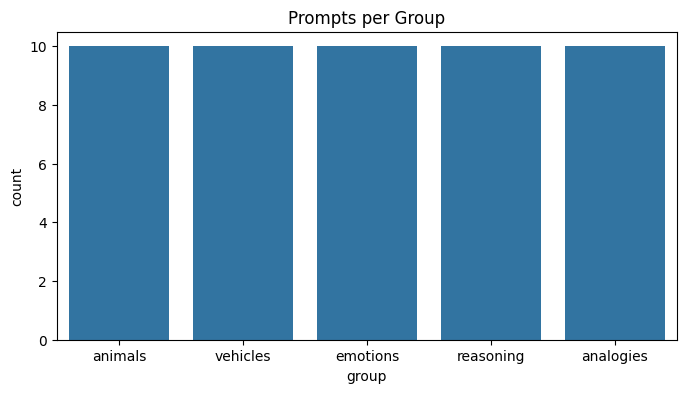

group
animals      10
vehicles     10
emotions     10
reasoning    10
analogies    10
Name: count, dtype: int64

In [2]:
# Group Counts
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='group', order=df['group'].value_counts().index)
plt.title('Prompts per Group')
plt.show()

df['group'].value_counts()

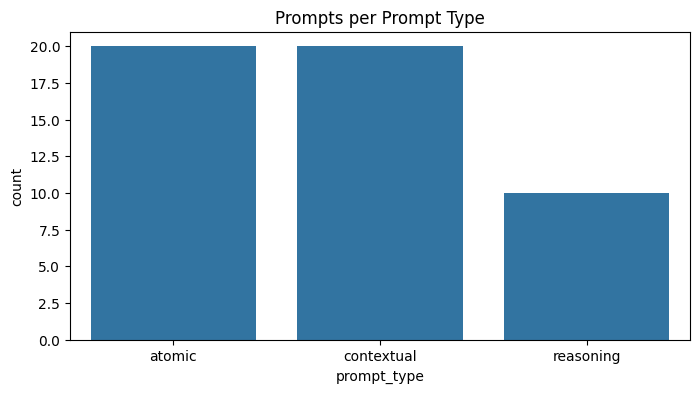

prompt_type
atomic        20
contextual    20
reasoning     10
Name: count, dtype: int64

In [3]:
# Prompt Type Counts
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='prompt_type', order=df['prompt_type'].value_counts().index)
plt.title('Prompts per Prompt Type')
plt.show()

df['prompt_type'].value_counts()

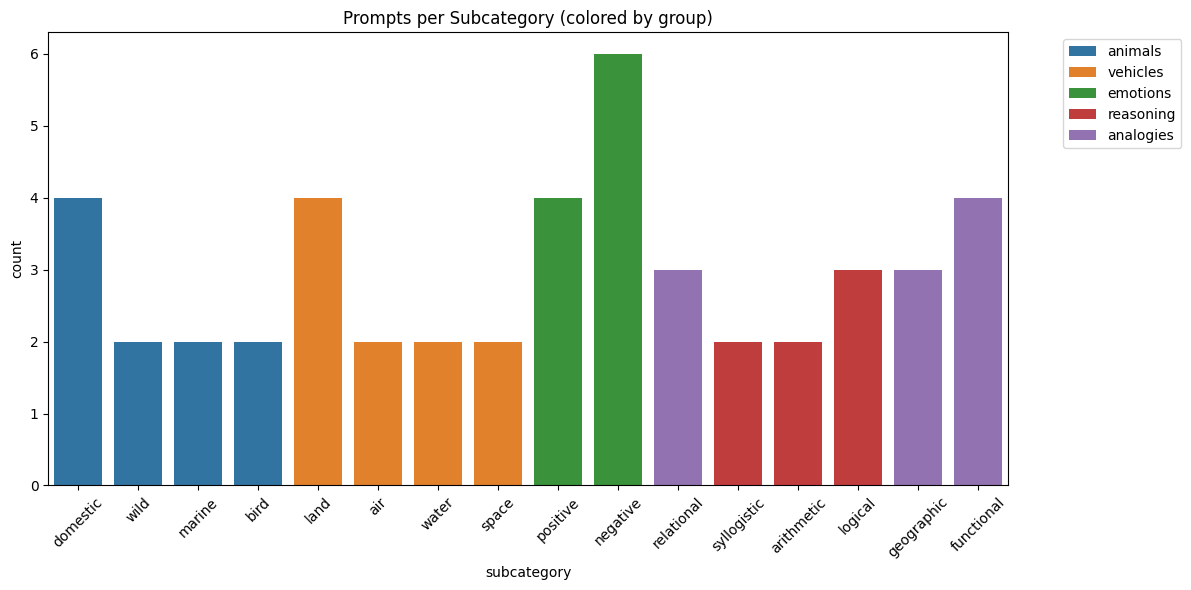

group      subcategory
analogies  functional     4
           geographic     3
           relational     3
animals    bird           2
           domestic       4
           marine         2
           wild           2
emotions   negative       6
           positive       4
reasoning  arithmetic     2
           logical        3
           relational     3
           syllogistic    2
vehicles   air            2
           land           4
           space          2
           water          2
dtype: int64

In [4]:
# Subcategory Counts
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='subcategory', hue='group', dodge=False)
plt.title('Prompts per Subcategory (colored by group)')
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

df.groupby(['group', 'subcategory']).size()

In [5]:
# Example Prompts per Category
for group in df['group'].unique():
    print(f"\n--- {group.upper()} ---")
    sample = df[df['group'] == group].head(3)
    for _, row in sample.iterrows():
        print(f"[{row['prompt_type']} - {row['subcategory']}]: {row['prompt']}")


--- ANIMALS ---
[atomic - domestic]: cat
[atomic - wild]: lion
[atomic - marine]: dolphin

--- VEHICLES ---
[atomic - land]: car
[atomic - air]: airplane
[atomic - water]: ship

--- EMOTIONS ---
[atomic - positive]: happy
[atomic - negative]: sad
[atomic - negative]: angry

--- REASONING ---
[reasoning - relational]: If A > B and B > C, which is larger?
[reasoning - syllogistic]: If all roses are flowers and all flowers are plants, are roses plants?
[reasoning - relational]: If John is older than Mary and Mary is older than Tom, who is youngest?

--- ANALOGIES ---
[atomic - relational]: King : Queen
[atomic - relational]: Man : Woman
[atomic - geographic]: Paris : France


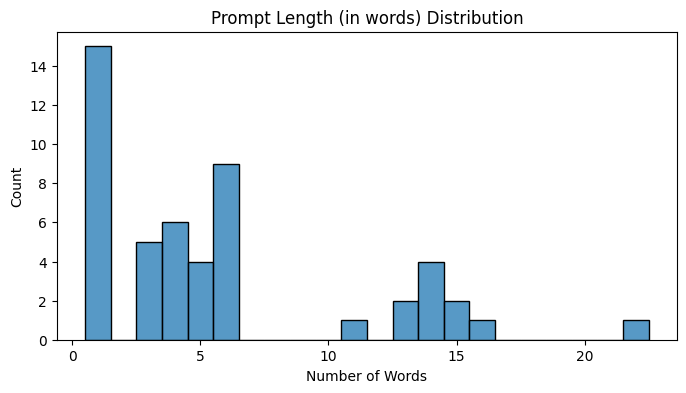

count    50.000000
mean      5.780000
std       5.234462
min       1.000000
25%       1.000000
50%       4.000000
75%       6.000000
max      22.000000
Name: prompt_length, dtype: float64

In [6]:
# Prompt Length Histogram
df['prompt_length'] = df['prompt'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 4))
sns.histplot(df['prompt_length'], bins=range(1, df['prompt_length'].max() + 2), discrete=True)
plt.title('Prompt Length (in words) Distribution')
plt.xlabel('Number of Words')
plt.ylabel('Count')
plt.show()

df['prompt_length'].describe()